## Geospacial test

In [61]:
import geopandas as gpd
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point
import json
from shapely.geometry import LineString, MultiLineString
import momepy

/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Functions that being used

In [44]:
def shape_to_geom(shape):
    # shape is like: {"coordinates": [[[lon,lat], [lon,lat], ...]]}
    if shape is None or (isinstance(shape, float) and str(shape) == "nan"):
        return None
    if isinstance(shape, str):
        shape = json.loads(shape)

    coords = shape.get("coordinates", None)
    if not coords:
        return None

    # Most common here: coords = [ [ [lon,lat], [lon,lat], ... ] ]
    # Sometimes it can be multiple parts -> MultiLineString
    if isinstance(coords[0][0][0], (int, float)):  # [[[lon,lat],...]] -> coords[0][0] is lon
        return LineString(coords[0])
    else:
        return MultiLineString([LineString(part) for part in coords])

### Code for plotting

In [32]:
## Load in the dataframe
#brussels = pd.read_csv('Brussels_gtfs-routes-production.csv', sep=";")
brussels = gpd.read_file('Brussels_gtfs-routes-production.csv')

## Make the 'geo_point_2d' column into lat and lon columns
brussels[["lat", "lon"]] = (
    brussels["geo_point_2d"]
    .str.split(",", expand=True)
    .astype(float)
)

## Make the GeoDataFrame from the newly defined columns
brussels = gpd.GeoDataFrame(
    brussels,
    geometry=gpd.points_from_xy(brussels.lon, brussels.lat),
    crs="EPSG:4326"  # standard lat/lon
)

In [66]:
## Used to inspect the structure of the newly created geopandas dataframe 
#brussels

In [ ]:
## See the crs - its the 'EPSG:xxxx' format. Also achived via print(df.crs)
brussels.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
# Isolate the geometry from the 'Shape' column so we can see the lines instead of the points
brussels["geometry"] = brussels["Shape"].apply(shape_to_geom)

# Build GeoDataFrame with WGS84 (lon/lat)
routes_gdf = gpd.GeoDataFrame(brussels, geometry="geometry", crs="EPSG:4326")

# Drop rows that still have no geometry
routes_gdf = routes_gdf[~routes_gdf.geometry.isna()].copy()

### Plotting

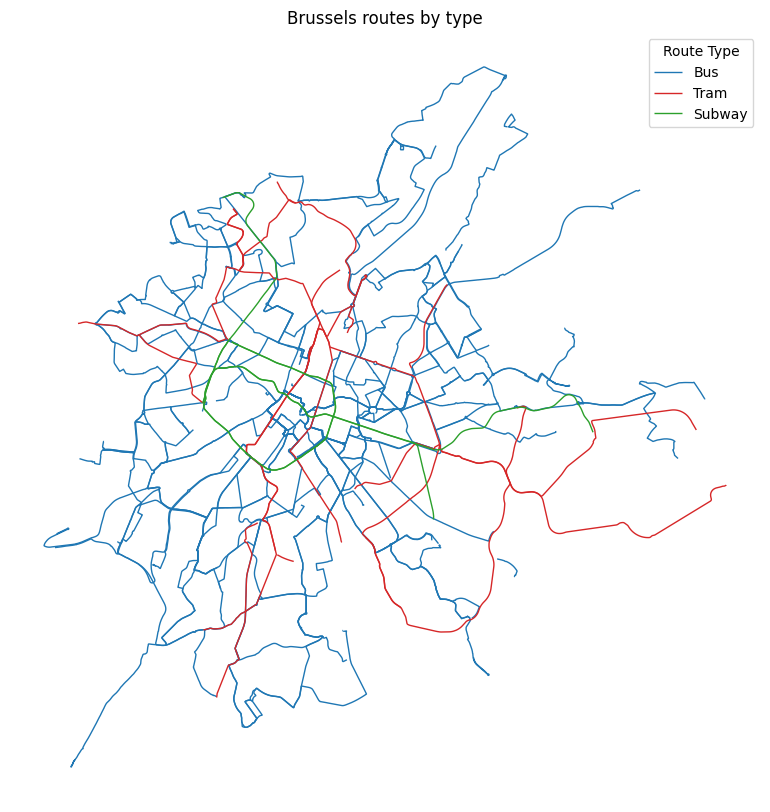

In [51]:
color_map = {
    "Bus": "#1f77b4",
    "Tram": "#d62728",
    "Subway": "#2ca02c"
}

fig, ax = plt.subplots(figsize=(10, 10))

for route_type, color in color_map.items():
    routes_gdf[routes_gdf["Route Type"] == route_type].plot(
        ax=ax,
        color=color,
        linewidth=1,
        label=route_type
    )

ax.legend(title="Route Type")
ax.set_title("Brussels routes by type")
ax.set_axis_off()
plt.show()

#### Show only selected transportation types

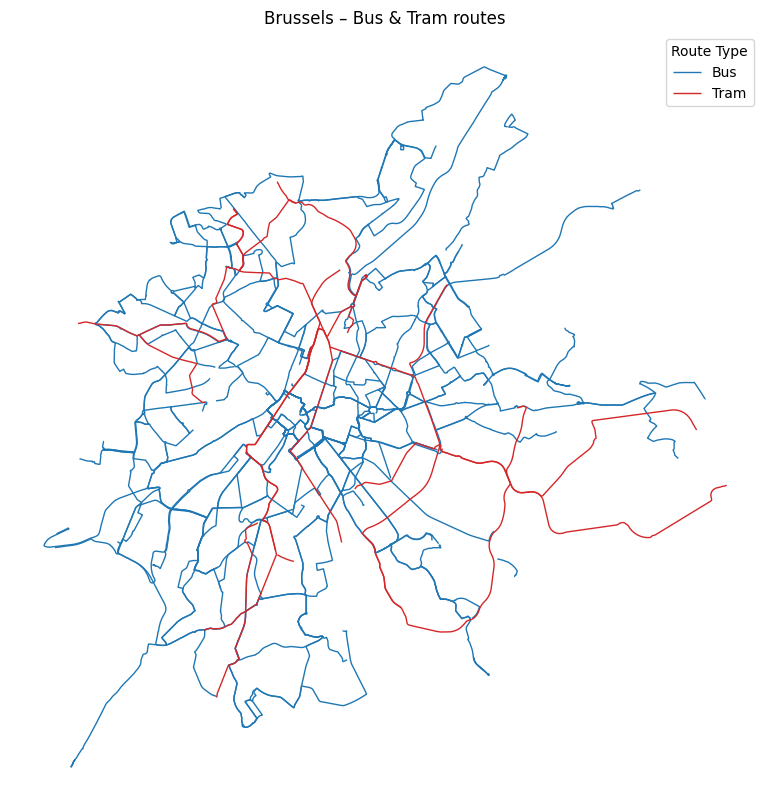

In [ ]:
## What needs to be edited so only selected types and colors are shown in the plot
Transport_types = ["Bus", "Tram"]

color_map = {
    "Bus": "#1f77b4",
    "Tram": "#d62728"
}

## Craeting the plot based on the selected types and colors
subset = routes_gdf[routes_gdf["Route Type"].isin(Transport_types)]

fig, ax = plt.subplots(figsize=(10, 10))

for rt, color in color_map.items():
    sub = subset[subset["Route Type"] == rt]
    if not sub.empty:
        sub.plot(ax=ax, color=color, linewidth=1, label=rt)

ax.legend(title="Route Type")
ax.set_title("Brussels – Bus & Tram routes")
ax.set_axis_off()
plt.show()

#### Project it onto the actual map of Brussels

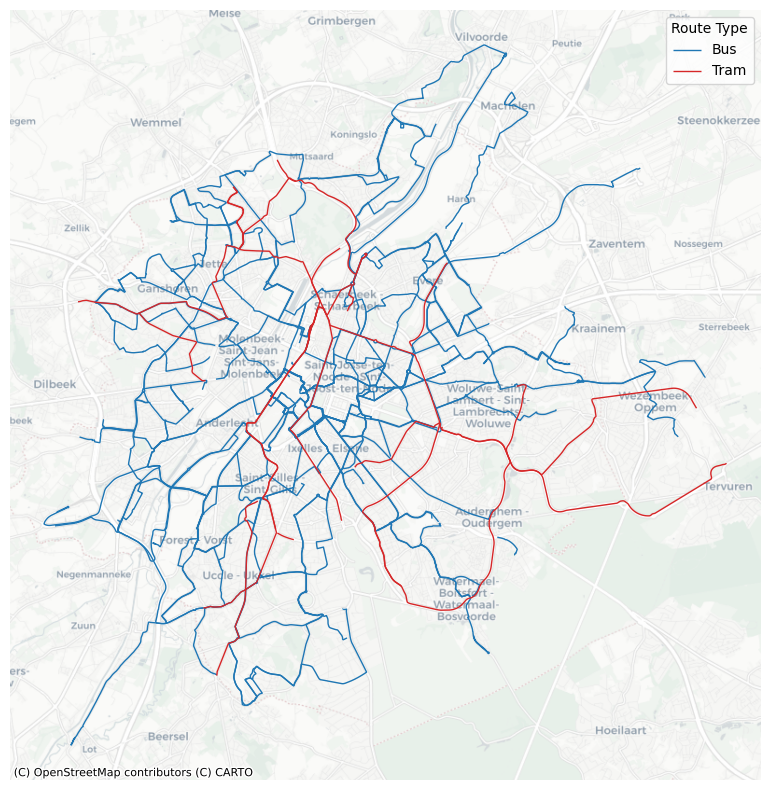

In [ ]:
# This is a important import for the projection on an actual map
import contextily as cx

routes_3857 = routes_gdf.to_crs(epsg=3857)

color_map = {
    "Bus": "#1f77b4",
    "Tram": "#d62728"
}

fig, ax = plt.subplots(figsize=(10, 10))

for rt, color in color_map.items():
    sub = routes_3857[routes_3857["Route Type"] == rt]
    if not sub.empty:
        sub.plot(ax=ax, color=color, linewidth=1, label=rt)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.legend(title="Route Type")
ax.set_axis_off()
plt.show()

### Using NetworkX to plot
This isnt quite there yet. Some stuff needs editing. 
Wroking from this link: https://networkx.org/documentation/stable/auto_examples/geospatial/plot_lines.html

/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/momepy/utils.py:351: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length
/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/libpysal/weights/weights.py:1683: UserWarning: The weights matrix is not fully connected: 
 There are 69 disconnected components.
  w = W(neighbors, weights, ids, silence_warnings=silence_warnings)
/home/jspe/venvs/Bachelor_project/lib/python3.11/site-packages/momepy/utils.py:351: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_network[length] = gdf_network.geometry.length


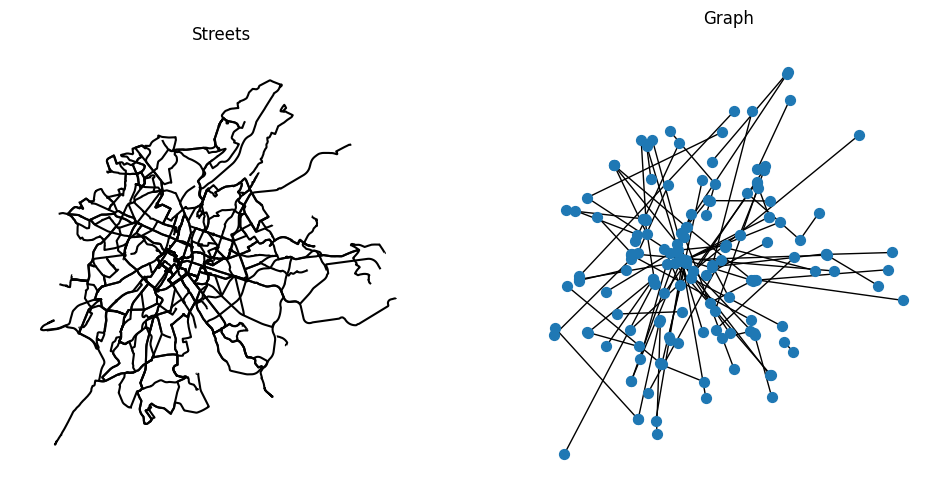

In [68]:
# Read in the brussels geodataframe to networkX
G = momepy.gdf_to_nx(brussels, approach="primal")

nodes, edges, W = momepy.nx_to_gdf(G, spatial_weights=True)

# Read in example street network from GeoPackage

# Construct the primal graph
G_primal = momepy.gdf_to_nx(routes_gdf, approach="primal")

# Plot
f, ax = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
routes_gdf.plot(color="k", ax=ax[0])
for i, facet in enumerate(ax):
    facet.set_title(("Streets", "Graph")[i])
    facet.axis("off")
    try:  # For issues with downloading/parsing in CI
        add_basemap(facet)
    except:
        pass
nx.draw(
    G_primal, {n: [n[0], n[1]] for n in list(G_primal.nodes)}, ax=ax[1], node_size=50
)

## Potential Facit

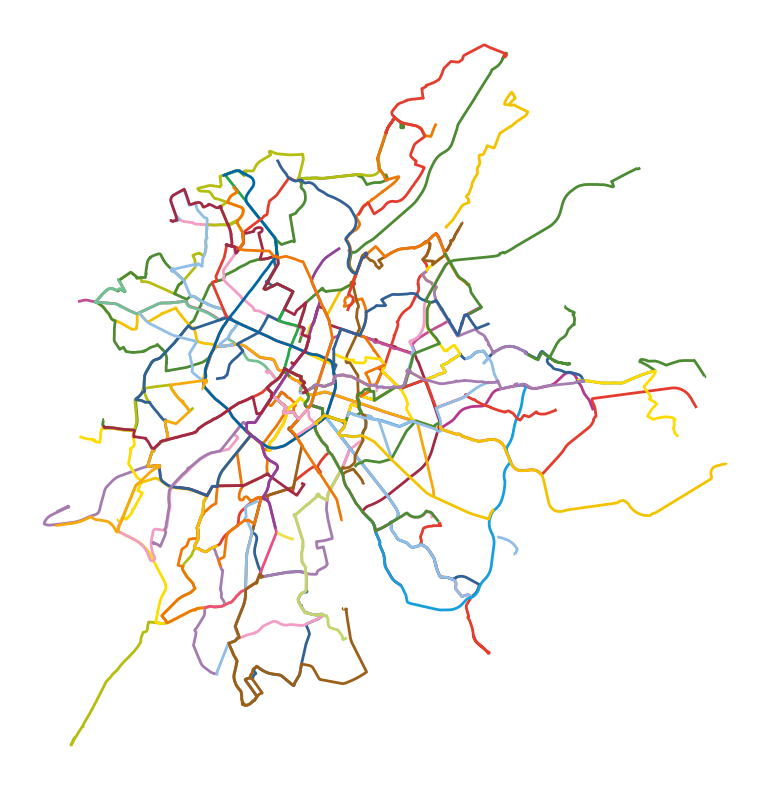

In [ ]:
######### ChatGPT generated code #########
def shape_to_geom(shape):
    # shape is like: {"coordinates": [[[lon,lat], [lon,lat], ...]]}
    if shape is None or (isinstance(shape, float) and str(shape) == "nan"):
        return None
    if isinstance(shape, str):
        shape = json.loads(shape)

    coords = shape.get("coordinates", None)
    if not coords:
        return None

    # Most common here: coords = [ [ [lon,lat], [lon,lat], ... ] ]
    # Sometimes it can be multiple parts -> MultiLineString
    if isinstance(coords[0][0][0], (int, float)):  # [[[lon,lat],...]] -> coords[0][0] is lon
        return LineString(coords[0])
    else:
        return MultiLineString([LineString(part) for part in coords])

routes_gdf = gpd.GeoDataFrame(
    brussels.copy(),
    geometry=brussels["Shape"].apply(shape_to_geom),
    crs="EPSG:4326"
).dropna(subset=["geometry"])

# Make colors valid hex for matplotlib
routes_gdf["plot_color"] = routes_gdf["Color"].astype(str).apply(
    lambda c: ("#" + c) if (len(c) == 6 and c != "nan" and not c.startswith("#")) else "#3366cc"
)

fig, ax = plt.subplots(figsize=(10, 10))
for _, row in routes_gdf.iterrows():
    gpd.GeoSeries([row.geometry], crs=routes_gdf.crs).plot(ax=ax, linewidth=2, color=row.plot_color)

ax.set_axis_off()
plt.show()


## Copenhagen

In [ ]:
## Might not work
## ChatGPT chat: CSV Parsing Error Fix

from rdflib import Graph

g = Graph()
g.parse("metadata_dcat.xml", format="xml")